# DengAI - Exploratory Data Analysis

Forecasting weekly dengue case counts in two cities: **San Juan, Puerto Rico (`sj`)** and
**Iquitos, Peru (`iq`)**.

**Task.** For each `(city, year, weekofyear)` row, predict `total_cases`. Predictions for both
cities are concatenated into a single submission. The competition is scored with
**Mean Absolute Error (MAE)**.

**Where the data comes from.** This is the San Juan / Iquitos dengue surveillance data assembled
for the NOAA/CDC dengue forecasting challenge (Johansson et al., *PNAS* 2019). The DrivenData
"DengAI" competition repackages it with aligned climate covariates from several sources
(NOAA GHCN stations, PERSIANN satellite precipitation, NCEP CFSR reanalysis, and NDVI vegetation).

---
### GData

```
data/
  dengue_features_train.csv
  dengue_labels_train.csv
  dengue_features_test.csv
  submission_format.csv
```

In [27]:
# --- Imports & display settings -------------------------------------------------
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.max_columns", 60)

RANDOM_STATE = 42

In [28]:
# --- Locate and load the data ---------------------------------------------------
# Multi-index is (city, year, weekofyear); week_start_date stays as a column.
CANDIDATE_DIRS = ["../data"]
FILES = {
    "features_train": "dengue_features_train.csv",
    "labels_train":   "dengue_labels_train.csv",
    "features_test":  "dengue_features_test.csv",
    "submission":     "submission_format.csv",
}

def find_data_dir():
    for d in CANDIDATE_DIRS:
        p = Path(d)
        if (p / FILES["features_train"]).exists() and (p / FILES["labels_train"]).exists():
            return p
    raise FileNotFoundError(
        "Could not find dengue_features_train.csv / dengue_labels_train.csv.\n"
        "Download the four CSVs from the DrivenData 'DengAI' competition Data tab "
        "and place them in a 'data/' folder next to this notebook (see intro)."
    )

DATA_DIR = find_data_dir()
print("Loading from:", DATA_DIR.resolve())

idx = ["city", "year", "weekofyear"]
features_train = pd.read_csv(DATA_DIR / FILES["features_train"], index_col=idx, parse_dates=["week_start_date"])
labels_train   = pd.read_csv(DATA_DIR / FILES["labels_train"],   index_col=idx)

features_test = submission = None
if (DATA_DIR / FILES["features_test"]).exists():
    features_test = pd.read_csv(DATA_DIR / FILES["features_test"], index_col=idx, parse_dates=["week_start_date"])
if (DATA_DIR / FILES["submission"]).exists():
    submission = pd.read_csv(DATA_DIR / FILES["submission"], index_col=idx)

train = features_train.join(labels_train)
print("train:", train.shape, "| test:", None if features_test is None else features_test.shape)
train.head()

Loading from: C:\Users\matthias\Documents\Akademischer Mitarbeiter\Klausurtagung\deng-ai-team-1\data
train: (1456, 22) | test: (416, 21)


week_start_date   ndvi_ne   ndvi_nw   ndvi_se   ndvi_sw  \
city year weekofyear                                                           
sj   1990 18              1990-04-30  0.122600  0.103725  0.198483  0.177617   
          19              1990-05-07  0.169900  0.142175  0.162357  0.155486   
          20              1990-05-14  0.032250  0.172967  0.157200  0.170843   
          21              1990-05-21  0.128633  0.245067  0.227557  0.235886   
          22              1990-05-28  0.196200  0.262200  0.251200  0.247340   

                      precipitation_amt_mm  reanalysis_air_temp_k  \
city year weekofyear                                                
sj   1990 18                         12.42             297.572857   
          19                         22.82             298.211429   
          20                         34.54             298.781429   
          21                         15.36             298.987143   
          22                          7.52             299.518571   

                      reanalysis_avg_temp_k  reanalysis_dew_point_temp_k  \
city year weekofyear                                                       
sj   1990 18                     297.742857                   292.414286   
          19                     298.442857                   293.951429   
          20                     298.878571                   295.434286   
          21                     299.228571                   295.310000   
          22                     299.664286                   295.821429   

                      reanalysis_max_air_temp_k  reanalysis_min_air_temp_k  \
city year weekofyear                                                         
sj   1990 18                              299.8                      295.9   
          19                              300.9                      296.4   
          20                              300.5                      297.3   
          21                              301.4                      297.0   
          22                              301.9                      297.5   

                      reanalysis_precip_amt_kg_per_m2  \
city year weekofyear                                    
sj   1990 18                                    32.00   
          19                                    17.94   
          20                                    26.10   
          21                                    13.90   
          22                                    12.20   

                      reanalysis_relative_humidity_percent  \
city year weekofyear                                         
sj   1990 18                                     73.365714   
          19                                     77.368571   
          20                                     82.052857   
          21                                     80.337143   
          22                                     80.460000   

                      reanalysis_sat_precip_amt_mm  \
city year weekofyear                                 
sj   1990 18                                 12.42   
          19                                 22.82   
          20                                 34.54   
          21                                 15.36   
          22                                  7.52   

                      reanalysis_specific_humidity_g_per_kg  \
city year weekofyear                                          
sj   1990 18                                      14.012857   
          19                                      15.372857   
          20                                      16.848571   
          21                                      16.672857   
          22                                      17.210000   

                      reanalysis_tdtr_k  station_avg_temp_c  \
city year weekofyear                                          
sj   1990 18                   2.628571           25.442857   
          19                   2.371429           2

## 1. Per-city split

In [29]:
def split_cities(df):
    return df.loc["sj"].copy(), df.loc["iq"].copy()

sj, iq = split_cities(train)

for name, d in [("San Juan", sj), ("Iquitos", iq)]:
    yrs = (d["week_start_date"].min().date(), d["week_start_date"].max().date())
    print(f"{name:9s} rows={len(d):4d}  span={yrs[0]} -> {yrs[1]}  "
          f"total_cases: mean={d['total_cases'].mean():5.1f}  max={d['total_cases'].max():4d}")

San Juan  rows= 936  span=1990-04-30 -> 2008-04-22  total_cases: mean= 34.2  max= 461
Iquitos   rows= 520  span=2000-07-01 -> 2010-06-25  total_cases: mean=  7.6  max= 116


In [30]:
# Feature columns we will actually model on (everything except the date column + target)
feature_cols = [c for c in features_train.columns if c != "week_start_date"]
print(f"{len(feature_cols)} candidate features:")
for c in feature_cols:
    print("  ", c)

20 candidate features:
   ndvi_ne
   ndvi_nw
   ndvi_se
   ndvi_sw
   precipitation_amt_mm
   reanalysis_air_temp_k
   reanalysis_avg_temp_k
   reanalysis_dew_point_temp_k
   reanalysis_max_air_temp_k
   reanalysis_min_air_temp_k
   reanalysis_precip_amt_kg_per_m2
   reanalysis_relative_humidity_percent
   reanalysis_sat_precip_amt_mm
   reanalysis_specific_humidity_g_per_kg
   reanalysis_tdtr_k
   station_avg_temp_c
   station_diur_temp_rng_c
   station_max_temp_c
   station_min_temp_c
   station_precip_mm


## 2. The target: `total_cases`

Two things drive every later modelling decision: the series is **highly seasonal** with sporadic
large outbreaks, and the counts are **overdispersed** (variance >> mean). The latter is why plain
Gaussian/MSE regression tends to underperform count-aware approaches here.

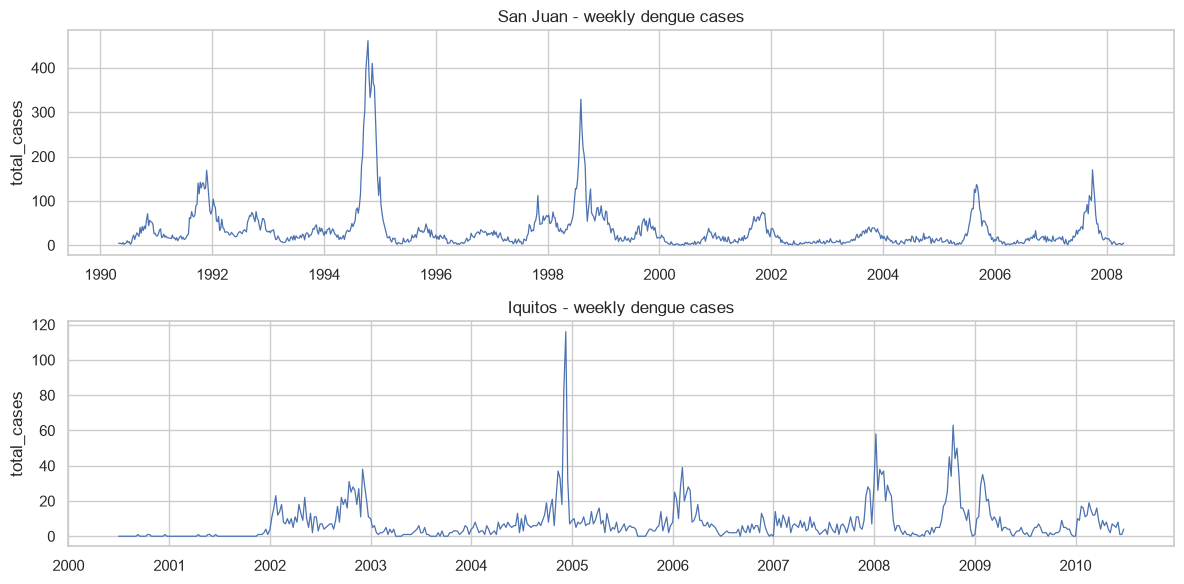

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
for ax, (name, d) in zip(axes, [("San Juan", sj), ("Iquitos", iq)]):
    ax.plot(d["week_start_date"], d["total_cases"], lw=0.9)
    ax.set_title(f"{name} - weekly dengue cases")
    ax.set_ylabel("total_cases")
plt.tight_layout(); plt.show()

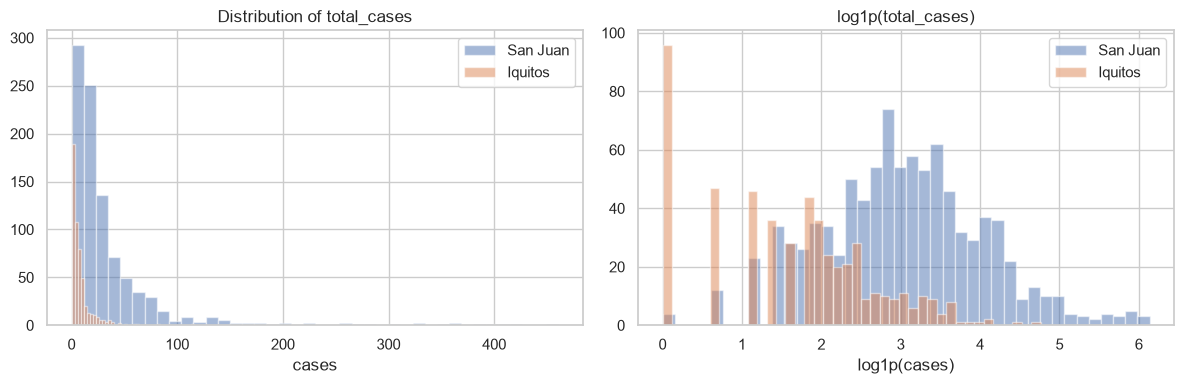

Mean vs variance (overdispersion if variance >> mean):
  San Juan  mean= 34.18  var= 2640.05  var/mean= 77.24
  Iquitos   mean=  7.57  var=  115.90  var/mean= 15.32


In [32]:
# Distribution + overdispersion check (Poisson assumes mean == variance)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, d in [("San Juan", sj), ("Iquitos", iq)]:
    axes[0].hist(d["total_cases"], bins=40, alpha=0.5, label=name)
axes[0].set_title("Distribution of total_cases"); axes[0].set_xlabel("cases"); axes[0].legend()

for name, d in [("San Juan", sj), ("Iquitos", iq)]:
    axes[1].hist(np.log1p(d["total_cases"]), bins=40, alpha=0.5, label=name)
axes[1].set_title("log1p(total_cases)"); axes[1].set_xlabel("log1p(cases)"); axes[1].legend()
plt.tight_layout(); plt.show()

print("Mean vs variance (overdispersion if variance >> mean):")
for name, d in [("San Juan", sj), ("Iquitos", iq)]:
    m, v = d["total_cases"].mean(), d["total_cases"].var()
    print(f"  {name:9s} mean={m:6.2f}  var={v:8.2f}  var/mean={v/m:6.2f}")

## 3. Missing values

In [33]:
miss = pd.DataFrame({
    "San Juan": sj[feature_cols].isna().sum(),
    "Iquitos":  iq[feature_cols].isna().sum(),
})
miss["sj_%"] = (100 * miss["San Juan"] / len(sj)).round(1)
miss["iq_%"] = (100 * miss["Iquitos"] / len(iq)).round(1)
miss.sort_values("San Juan", ascending=False)

,San Juan,Iquitos,sj_%,iq_%
ndvi_ne,191,3,20.4,0.6
ndvi_nw,49,3,5.2,0.6
ndvi_se,19,3,2.0,0.6
ndvi_sw,19,3,2.0,0.6
precipitation_amt_mm,9,4,1.0,0.8
reanalysis_sat_precip_amt_mm,9,4,1.0,0.8
reanalysis_avg_temp_k,6,4,0.6,0.8
reanalysis_air_temp_k,6,4,0.6,0.8
reanalysis_max_air_temp_k,6,4,0.6,0.8
reanalysis_min_air_temp_k,6,4,0.6,0.8


In [34]:
# Time-aware imputation, done per city so we never interpolate across the sj/iq boundary
def impute(d):
    d = d.sort_values("week_start_date").copy()
    d[feature_cols] = (d[feature_cols]
                       .interpolate(method="linear", limit_direction="both"))
    return d

sj_i, iq_i = impute(sj), impute(iq)
assert sj_i[feature_cols].isna().sum().sum() == 0
assert iq_i[feature_cols].isna().sum().sum() == 0
print("All feature NaNs filled. (Note: in a real pipeline, fit imputation on train only.)")

All feature NaNs filled. (Note: in a real pipeline, fit imputation on train only.)


## 4. Climate covariates over time

A quick look at a few of the most epidemiologically relevant drivers - humidity, temperature and
precipitation - the things that govern mosquito breeding and the virus's extrinsic incubation.

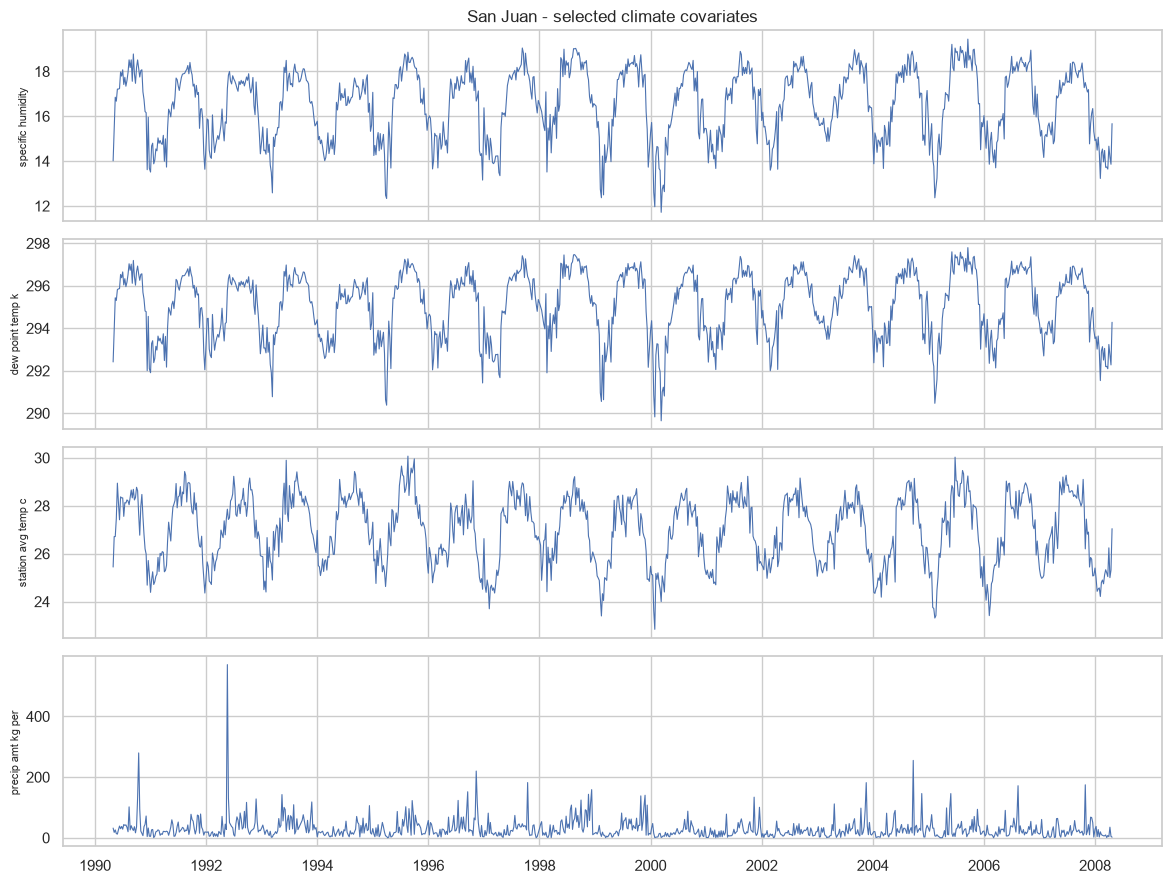

In [35]:
show = [
    "reanalysis_specific_humidity_g_per_kg",
    "reanalysis_dew_point_temp_k",
    "station_avg_temp_c",
    "reanalysis_precip_amt_kg_per_m2",
]
fig, axes = plt.subplots(len(show), 1, figsize=(12, 9), sharex=True)
for ax, col in zip(axes, show):
    ax.plot(sj_i["week_start_date"], sj_i[col], lw=0.8)
    ax.set_ylabel(col.replace("reanalysis_", "").replace("_", " ")[:18], fontsize=8)
axes[0].set_title("San Juan - selected climate covariates")
plt.tight_layout(); plt.show()

## 5. Seasonality

Dengue is strongly seasonal. Two complementary views:
- **Week-of-year boxplots** show the recurring annual shape (and which weeks carry the outbreak risk).
- **ACF / PACF** of the case series quantify autocorrelation - how strongly this week's count is
  predicted by recent weeks and by the same week last year. This is exactly the structure a
  SARIMA-type model exploits, and a strong hint about useful lag features for an ML model.

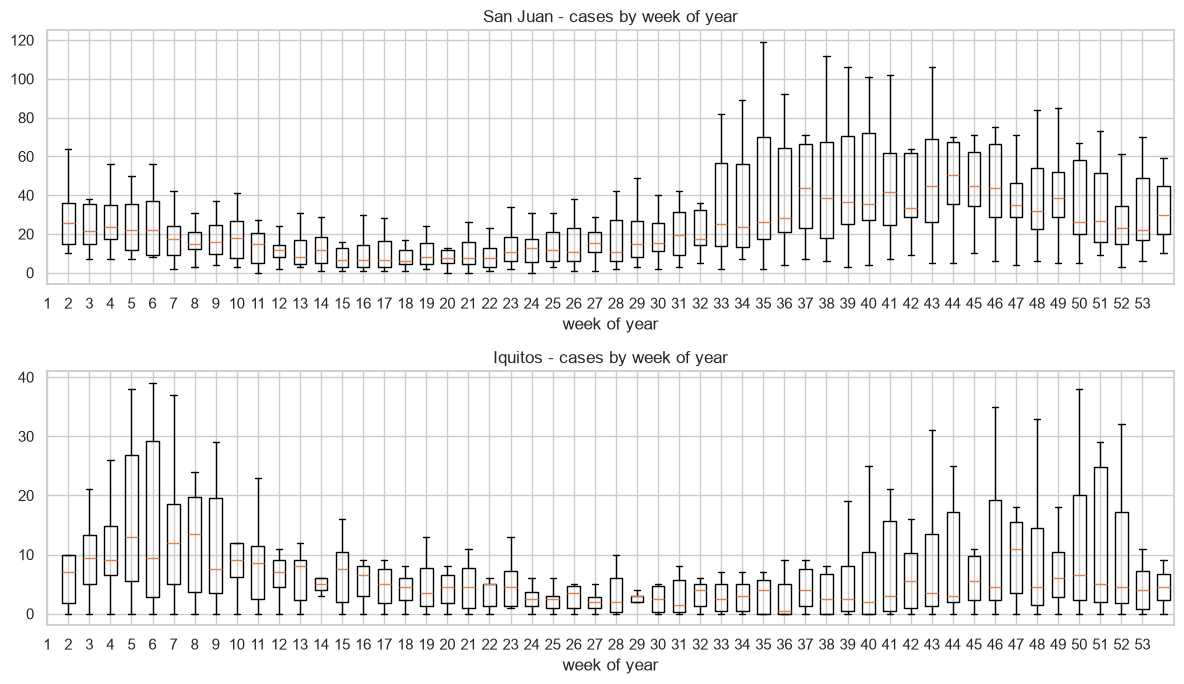

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
for ax, (name, d) in zip(axes, [("San Juan", sj), ("Iquitos", iq)]):
    order = sorted(d.index.get_level_values("weekofyear").unique())
    data = [d.loc[d.index.get_level_values("weekofyear") == w, "total_cases"] for w in order]
    ax.boxplot(data, positions=order, widths=0.6, showfliers=False)
    ax.set_title(f"{name} - cases by week of year"); ax.set_xlabel("week of year")
    ax.set_xticks(range(0, 53, 1))
plt.tight_layout()
plt.show()

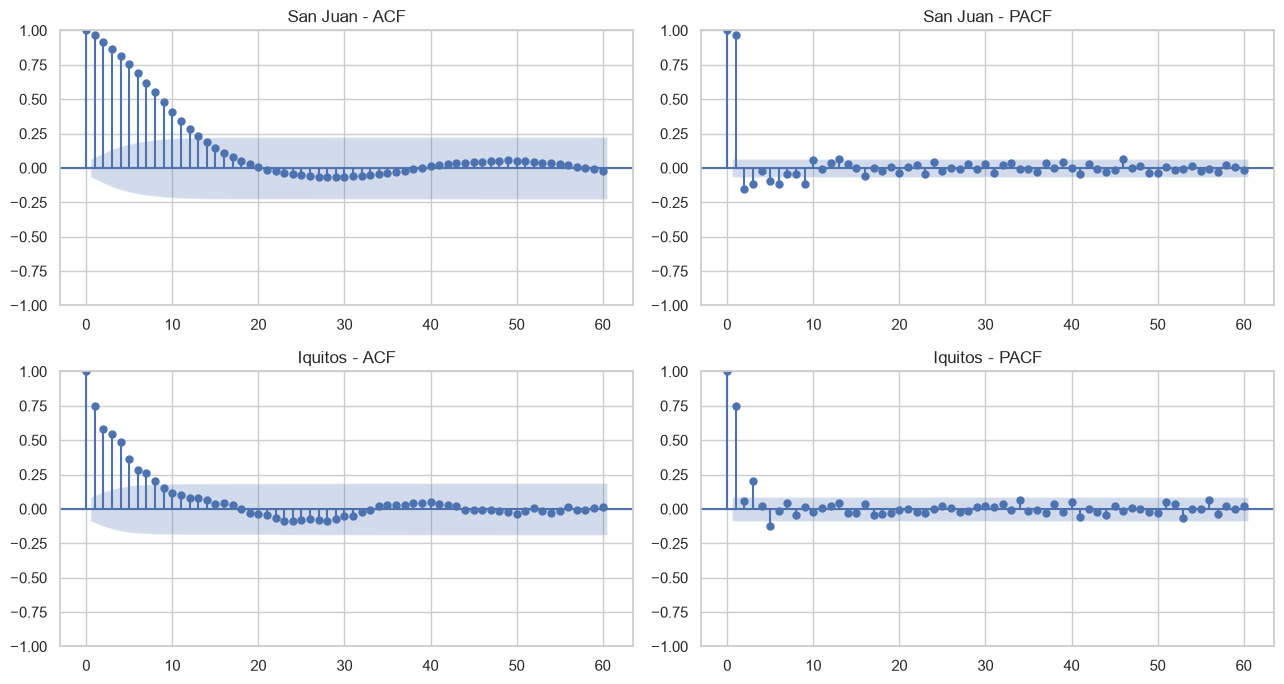

In [37]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for row, (name, d) in enumerate([("San Juan", sj), ("Iquitos", iq)]):
    y = d.sort_values("week_start_date")["total_cases"]
    plot_acf(y, lags=60, ax=axes[row, 0]); axes[row, 0].set_title(f"{name} - ACF")
    plot_pacf(y, lags=60, ax=axes[row, 1], method="ywm"); axes[row, 1].set_title(f"{name} - PACF")
plt.tight_layout(); plt.show()

## 6. Lagged cross-correlation: the biological lag

This is the most domain-relevant plot in the notebook. Climate does not affect cases *this* week -
it affects mosquito populations and viral incubation over the **following several weeks**. So we
correlate `total_cases` against each climate driver shifted *back* by `k` weeks, for `k = 0..25`,
and look for the lag where correlation peaks. That peak lag is a strong candidate for an
engineered lag feature.

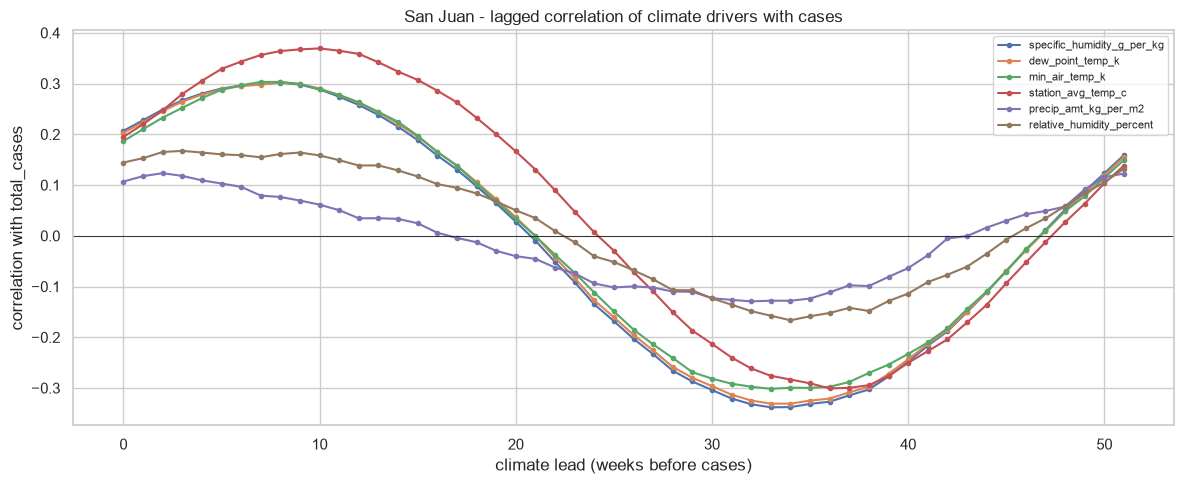

Lag (weeks) of peak |correlation| per driver, San Juan:
  reanalysis_specific_humidity_g_per_kg      lag=33  r=-0.338
  reanalysis_dew_point_temp_k                lag=33  r=-0.331
  reanalysis_min_air_temp_k                  lag= 8  r=+0.303
  station_avg_temp_c                         lag=10  r=+0.369
  reanalysis_precip_amt_kg_per_m2            lag=32  r=-0.129
  reanalysis_relative_humidity_percent       lag= 3  r=+0.167


In [38]:
drivers = [
    "reanalysis_specific_humidity_g_per_kg",
    "reanalysis_dew_point_temp_k",
    "reanalysis_min_air_temp_k",
    "station_avg_temp_c",
    "reanalysis_precip_amt_kg_per_m2",
    "reanalysis_relative_humidity_percent",
]
MAX_LAG = 52

def lag_corrs(d, col, max_lag=MAX_LAG):
    d = d.sort_values("week_start_date")
    y = d["total_cases"]
    return [d[col].shift(k).corr(y) for k in range(max_lag)]

fig, ax = plt.subplots(figsize=(12, 5))
for col in drivers:
    ax.plot(range(MAX_LAG), lag_corrs(sj_i, col), marker=".", label=col.replace("reanalysis_", ""))
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("climate lead (weeks before cases)"); ax.set_ylabel("correlation with total_cases")
ax.set_title("San Juan - lagged correlation of climate drivers with cases")
ax.legend(fontsize=8, loc="upper right"); plt.tight_layout(); plt.show()

print("Lag (weeks) of peak |correlation| per driver, San Juan:")
for col in drivers:
    cc = np.array(lag_corrs(sj_i, col))
    k = int(np.nanargmax(np.abs(cc)))
    print(f"  {col:42s} lag={k:2d}  r={cc[k]:+.3f}")

## 7. A seasonal-naive baseline

Before any model, anchor MAE with the cheapest sensible predictor: **for each week-of-year, predict
the historical mean cases for that week** (fit on a training slice, evaluate on the held-out tail).
The PNAS challenge found seasonal baselines surprisingly hard to beat - so this number is the bar
your model has to clear.

In [39]:
from sklearn.metrics import mean_absolute_error

def seasonal_naive_mae(d, holdout_frac=0.25):
    d = d.sort_values("week_start_date").reset_index()
    n_test = int(len(d) * holdout_frac)
    tr, te = d.iloc[:-n_test], d.iloc[-n_test:]
    woy_mean = tr.groupby("weekofyear")["total_cases"].mean()
    global_mean = tr["total_cases"].mean()
    pred = te["weekofyear"].map(woy_mean).fillna(global_mean)
    return mean_absolute_error(te["total_cases"], pred), n_test

for name, d in [("San Juan", sj), ("Iquitos", iq)]:
    mae, n_test = seasonal_naive_mae(d)
    print(f"{name:9s} seasonal-naive MAE on last {n_test} weeks: {mae:.2f}")

San Juan  seasonal-naive MAE on last 234 weeks: 24.88
Iquitos   seasonal-naive MAE on last 130 weeks: 7.74
